

<center>

# ZiSR: Klasyfikacja wektorów przy użyciu zbiorów rozmytych

---

## Jowita Kruk
### 339351

</center>


## 1. Cel
Celem projektu jest zbudowanie prostego klasyfikatora opartego na zbiorach rozmytych. Model wykorzystywać ma dane ze zbioru Iris i opierać się na:
- obliczeniu podstawowych statystyk dla każdej cechy i klasy (średnia, odchylenie standardowe, min, max),
- zbudowaniu funkcji przynależności,
- wygenerowaniu 12 wykresów zbiorów rozmytych (4 cechy x 3 klasy),
- implementacji klasyfikatora, który sumuje stopnie przynależności i wybiera klasę o najwyższym wyniku.

## 1. Teoria

### 1.1. Czym są zbiory rozmyte?
Zbiór rozmyty to rozszerzenie klasycznego pojęcia zbioru.
Zamiast odpowiedzi 0 *(nienależy)* bądź 1 *(należy)*, każdy element ma stopień przynależności ze zbioru **[0,1]**. Wartości pośrednie opisują częściową przynależność.

### 1.2. Funkcje przynależności
W projekcie wykorzystano trzy typy funkcji:
- Gaussowska.
- trójkątna,
- trapezowa.

Im bliżej wartości średniej znajduje się `x`, tym większy stopień przynależności.

## 2. Kod

### Importy i wczytanie danych Iris
Importowane są potrzebne biblioteki:
- numpy: obliczenia numeryczne,
- matplotlib: rysowanie wykresów,
- sklearn: wczytanie zbioru Iris.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Wczytujemy dane Iris (150 próbek, 4 cechy, 3 klasy)
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("Wczytano bazę danych Iris")
print(f"Liczba próbek: {X.shape[0]}")
print(f"Lista cech ({X.shape[1]}): {list(feature_names)}")
print(f"Lista klas ({len(class_names)}): {list(class_names)}")

Wczytano bazę danych Iris
Liczba próbek: 150
Lista cech (4): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Lista klas (3): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


### Implementacja funkcji przynależności
Poniżej zaimplementowane są 3 funkcje przynależności: Gaussowska, trapezowa i trójkątna.

#### Gausowsska:
x: wartość cechy

m: średnia *(środek zbioru)*

s: odchylenie standardowe *(szerokość zbioru)*

In [ ]:
def gauss(x, m, s):
    g = np.exp(-((x - m)**2) / (2 * s**2))
    return g

#### Trójkątna:
a: początek

b: środek *(`μ=1`)*

c: koniec


In [ ]:
def triangular(x, a, b, c):
    tri = np.maximum(np.minimum((x-a)/(b-a), (c-x)/(c-b)), 0)
    return tri

#### Trapezowa:

a: punkt, od którego wartość funkcji zaczyna rosnąć z 0

b: punkt, od którego funkcja osiąga maksymalną wartość 1

c: punkt, w którym kończy się maksymalna wartość 1

d: punkt, w którym funkcja spada z powrotem do 0


In [ ]:
def trapezoidal(x, a, b, c, d):
    tra = np.maximum(np.minimum(np.minimum((x-a)/(b-a), 1), (d-x)/(d-c)), 0)
    return tra

### Obliczanie statystyk dla każdej cechy i klasy
Dla każdej z 4 cech i 3 klas wyliczona ma być:
- średnia,
- odchylenie standardowe,
- minimum,
- maksimum.

In [ ]:
params = {}

for i, f_name in enumerate(feature_names):
    params[f_name] = {}

    for c_idx, c_name in enumerate(class_names):

        # Pobieranie wartości danej cechy dla danej klasy
        values = X[y == c_idx, i]

        # Obliczanie statystyk
        params[f_name][c_name] = {
            "mean": np.mean(values),
            "std": np.std(values),
            "min": np.min(values),
            "max": np.max(values)
        }

### Rysowanie 12 zbiorów rozmytych (4 cechy x 3 klasy)
Każdy wykres ma pokazać, jak wygląda zbiór rozmyty Gaussa dla danej cechy i klasy.

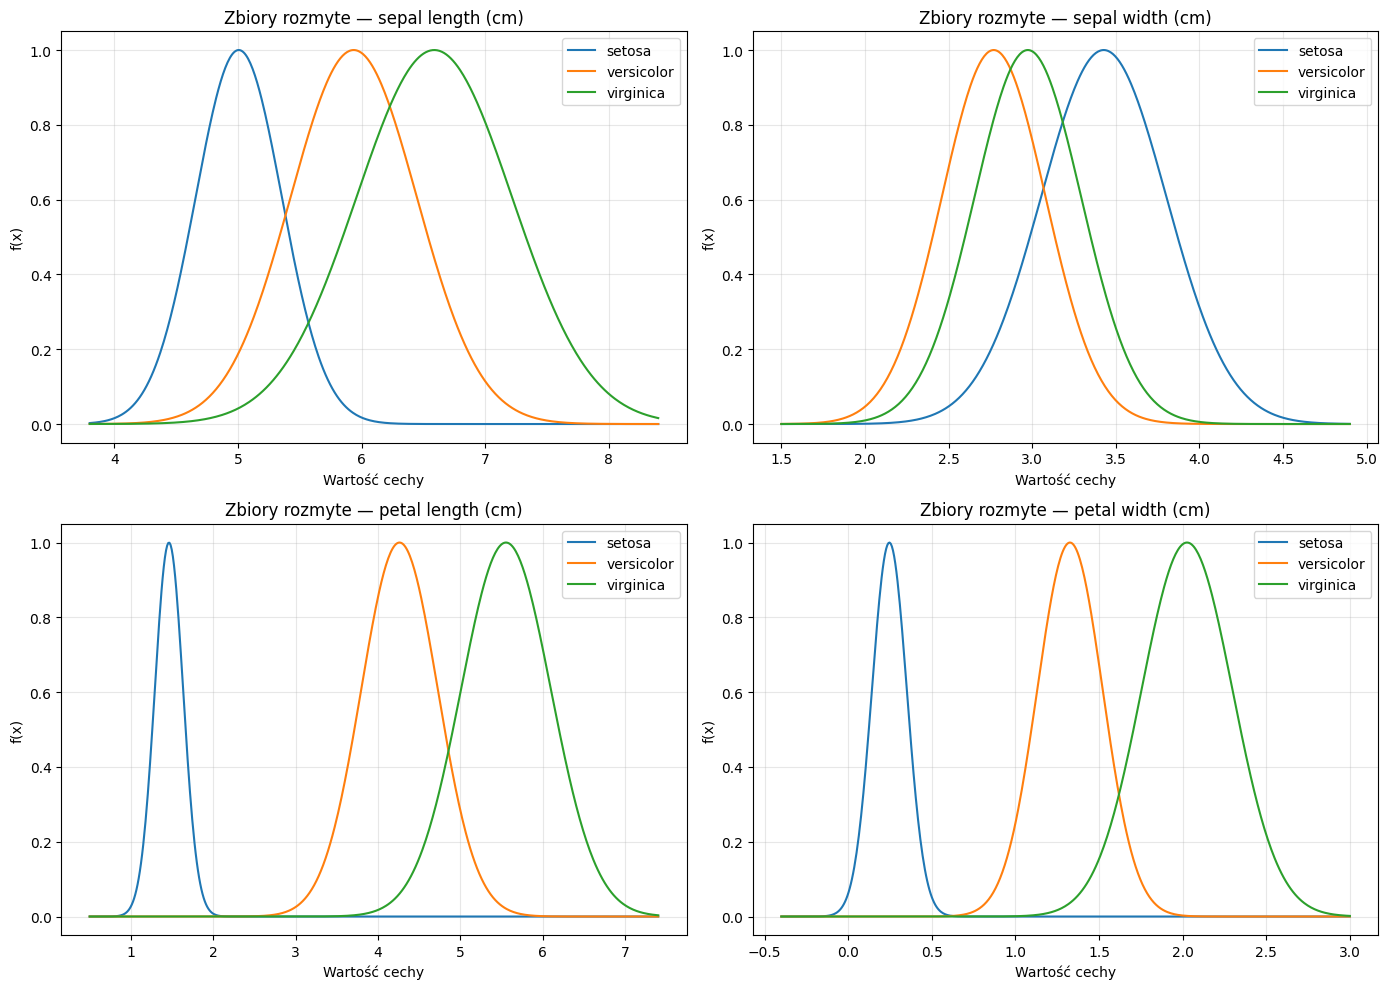

In [ ]:
# Tworzenie siatki wykresów 2x2 (bo 4 cechy)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Spłaszczanie tablicy osi (dla lepszej iteracji)
axes = axes.flatten()

for i, f_name in enumerate(feature_names):
    ax = axes[i]

    # Zakres osi X dla wykresu
    x_min = X[:, i].min() - 0.5 # dodanie marginesu 0,5
    x_max = X[:, i].max() + 0.5
    x = np.linspace(x_min, x_max, 500)

    # Rysowanie 3 funkcji przynależności (dla każdej klasy)
    for c_name in class_names:
        m = params[f_name][c_name]["mean"]
        s = params[f_name][c_name]["std"]

        y_vals = gauss(x, m, s)
        ax.plot(x, y_vals, label=c_name)

    ax.set_title(f"Zbiory rozmyte: {f_name}")
    ax.set_xlabel("Wartość cechy")
    ax.set_ylabel("f(x)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Implementacja klasyfikatora

In [ ]:
def classify(sample):
    # Na początku każda klasa ma wynik 0
    scores = {c: 0 for c in class_names}

    # Iterowanie po wszystkich cechach
    for i, f_name in enumerate(feature_names):
        val = sample[i]

        # Sprawdzanie przynależności do każdej klasy
        for c_name in class_names:
            # pobieranie średniej
            m = params[f_name][c_name]["mean"]
            # pobieranie odchylenia standardowego
            s = params[f_name][c_name]["std"]

            f = gauss(val, m, s)  # funkcja przynależności
            scores[c_name] += f   # sumowanie

    # wybieranie klasy z największą sumą
    return max(scores, key=scores.get), scores

### Test klasyfikacji

In [ ]:
# Wybór przykładowej próbki danych
test_sample = X[5]

# Klasyfikacja funkcji
pred, scores = classify(test_sample)

# Wynik
print("Próbka:", test_sample)
print("Wynik klasyfikacji:", pred)

print("Szczegóły:", scores)

Próbka: [5.4 3.9 1.7 0.4]
Wynik klasyfikacji: setosa
Szczegóły: {np.str_('setosa'): np.float64(1.7019631545809935), np.str_('versicolor'): np.float64(0.5782124713677368), np.str_('virginica'): np.float64(0.18339429175727084)}


## Wniosek
Zastosowany model klasyfikacji oparty na logice rozmytej pokazuje, że nawet prosta metoda wykorzystująca funkcje przynależności Gaussa może skutecznie rozróżniać gatunki kwiatów Iris. Dla każdej cechy obliczono średnią i odchylenie standardowe w obrębie każdej klasy, a następnie na ich podstawie zbudowano zbiory rozmyte. Wykresy funkcji przynależności pokazują, że klasy setosa, versicolor i virginica zajmują odmienne obszary przestrzeni cech, choć w przypadku dwóch ostatnich występują częściowe nakładania.

Wynik pokazuje, że próbka testowa została poprawnie przypisana do klasy o najwyższej łącznej przynależności, co potwierdza poprawność działania metody.

## Bilbliografia
1. Dr inż. Barbara Mrzygłód, **Inżynieria Wiedzy i Systemy Ekspertowe: _Podstawowe pojęcia z logiki rozmytej_**.
- https://home.agh.edu.pl/~mrzyglod/iw/iw_pliki/iw-is-ns-LR1-2019-2020.pdf
